In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('Dataset.csv')

In [28]:
df = df.drop(['Unnamed: 0', 'https'], axis = 1)

In [29]:
df.head(5)

,url_length,domain_length,subdomain_length,path_length,._count,-_count,__count,/_count,?_count,=_count,...,letter_count,special_char_count,digit_ratio,letter_ratio,has_ip,entropy,word_count,keyword_count,suspicious_tld,Target
0,139,3,3,139,3,10,2,3,0,0,...,109,22,0.057554,0.784173,0,4.707580,21,0,0,0
1,17,8,5,17,2,0,0,0,0,0,...,14,2,0.058824,0.823529,0,3.616875,3,0,0,1
2,56,6,0,56,3,0,1,5,0,0,...,27,9,0.357143,0.482143,0,4.662016,10,0,0,0
3,23,8,11,23,2,0,0,0,0,0,...,21,2,0.000000,0.913043,0,3.708132,3,0,0,1
4,16,8,3,16,2,0,0,0,0,0,...,12,2,0.125000,0.750000,0,3.500000,3,0,0,1


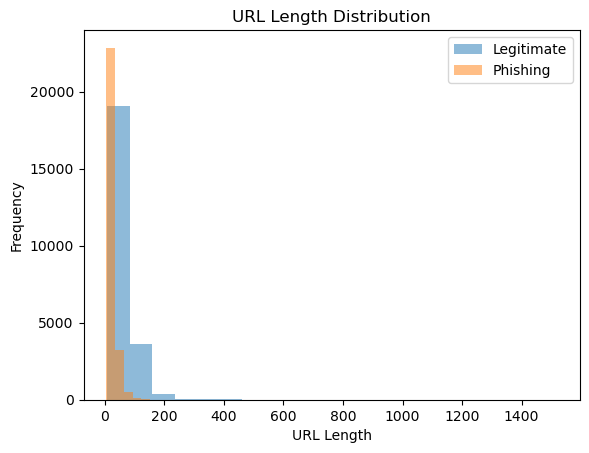

In [30]:
plt.figure()
plt.hist(df[df['Target']==0]['url_length'], bins=20, alpha=0.5)
plt.hist(df[df['Target']==1]['url_length'], bins=20, alpha=0.5)

plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.title("URL Length Distribution")
plt.legend(["Legitimate", "Phishing"])
plt.show()

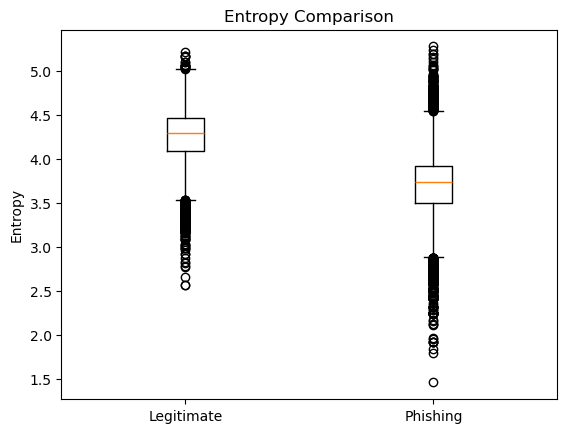

In [31]:
plt.figure()
plt.boxplot([df[df['Target']==0]['entropy'], df[df['Target']==1]['entropy']])

plt.xticks([1,2], ["Legitimate", "Phishing"])
plt.ylabel("Entropy")
plt.title("Entropy Comparison")
plt.show()

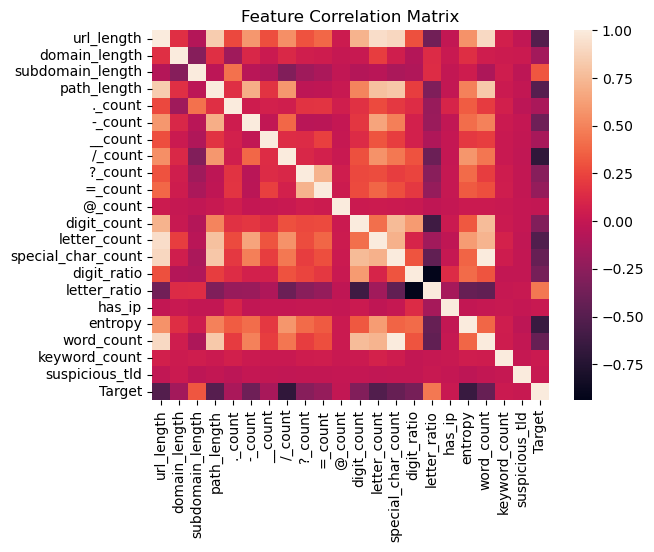

In [32]:
plt.figure()
corr = df.corr()
sns.heatmap(corr)

plt.title("Feature Correlation Matrix")
plt.show()

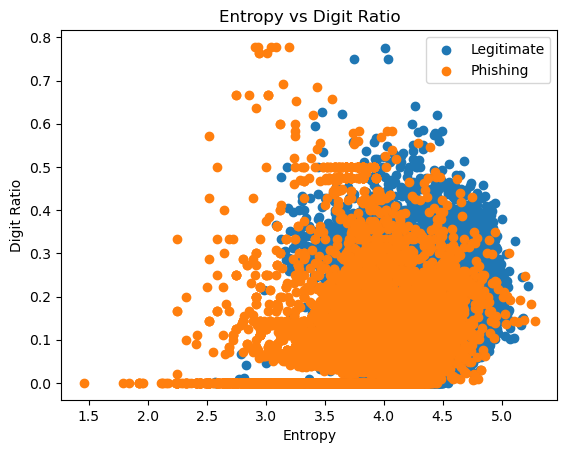

In [33]:
plt.figure()
plt.scatter(df[df['Target']==0]['entropy'], df[df['Target']==0]['digit_ratio'])
plt.scatter(df[df['Target']==1]['entropy'], df[df['Target']==1]['digit_ratio'])

plt.xlabel("Entropy")
plt.ylabel("Digit Ratio")
plt.title("Entropy vs Digit Ratio")
plt.legend(["Legitimate", "Phishing"])
plt.show()

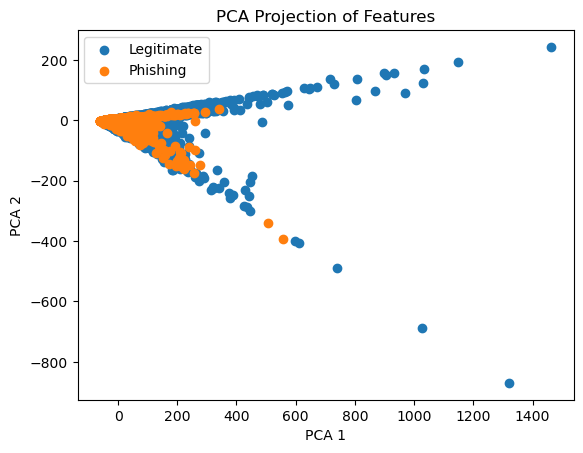

In [34]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.iloc[:, :-1])

plt.figure()
plt.scatter(X_pca[df['Target']==0,0], X_pca[df['Target']==0,1])
plt.scatter(X_pca[df['Target']==1,0], X_pca[df['Target']==1,1])

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Projection of Features")
plt.legend(["Legitimate", "Phishing"])
plt.show()